# Machine Learning Concepts
A structured, long-term learning notebook focused on general machine learning concepts, terminology, and practical workflows for Computer Engineering students.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn Imports
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, RocCurveDisplay, roc_curve
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set global random state for reproducibility
np.random.seed(42)

## 1. What Machine Learning Is

* **Machine Learning:** A subset of AI focused on building systems that learn from data to improve performance on a specific task without being explicitly programmed.
* **Supervised Learning:** Learning a mapping from input features to a known target output using labeled data. (e.g., Predicting house prices, identifying spam).
* **Unsupervised Learning:** Finding patterns or structures in data without predefined labels or targets. (e.g., Customer segmentation, anomaly detection).
* **Reinforcement Learning:** An agent learns to make decisions by performing actions in an environment to maximize cumulative reward. (e.g., Game playing, robot navigation).
* **Prediction vs Inference:** *Prediction* focuses strictly on accurately forecasting outcomes for new data. *Inference* focuses on understanding the relationship between features and the outcome.
* **Model:** The mathematical representation or function learned from data.
* **Algorithm:** The set of rules or mathematical optimization processes used to train the model.
* **Parameters:** Internal variables the model learns directly from the training data (e.g., coefficients in linear regression).
* **Hyperparameters:** External configurations set before training begins (e.g., tree depth, learning rate) that govern how the algorithm learns.
* **Training:** The process of optimizing the model's parameters using data to minimize errors.
* **Inference:** Applying the trained model to new, unseen data to generate predictions.
* **Generalization:** How well a model performs on unseen, new data compared to the training data.

## 2. The Standard Machine Learning Workflow

The machine learning lifecycle is highly structured. Order matters primarily to prevent **data leakage** (using future information during training).

1. **Problem Definition:** Establish the objective, metrics, and whether ML is actually necessary.
2. **Data Collection:** Gather representative data for the problem.
3. **Exploratory Data Analysis (EDA):** Understand distributions, correlations, missing values, and errors.
4. **Train-Validation-Test Split:** Isolate holdout sets *before* making preprocessing decisions to avoid leakage.
5. **Preprocessing:** Clean data, impute missing values, scale, and encode.
6. **Feature Selection / Engineering:** Create new predictive attributes or select the most relevant ones.
7. **Baseline Model:** Train a simple, naive model to establish a minimum performance floor.
8. **Training:** Fit more complex ML algorithms to the training data.
9. **Evaluation:** Assess model performance on the validation set using chosen metrics.
10. **Tuning:** Adjust hyperparameters to improve the validation score.
11. **Final Testing:** Evaluate the finalized model *once* on the untouched test set to estimate real-world generalization.
12. **Deployment:** Integrate the model into production systems.
13. **Monitoring:** Track real-world performance over time to detect data drift and model degradation.

## 3. Features and Targets

* **Feature:** An individual measurable property or characteristic of a phenomenon being observed (columns in a dataset).
* **Target / Label:** The desired output or variable we are trying to predict.
* **Sample / Observation / Instance:** A single data point containing a set of features (rows in a dataset).
* **Feature Matrix ($X$):** A 2D array (often a pandas DataFrame) containing only the features for all samples.
* **Target Vector ($y$):** A 1D array (often a pandas Series) containing the target values for all samples.
* **Numerical Features:** Continuous or discrete numbers with mathematical meaning (e.g., age, income).
* **Categorical Features:** Qualitative variables representing categories (e.g., color, country).
* **Ordinal Features:** Categorical variables with a clear, meaningful order (e.g., low, medium, high).
* **Binary Features:** Features taking exactly two possible values (e.g., True/False, 0/1).

In [5]:
# Creating a small synthetic DataFrame
data = {
    'Age': [25, 32, 47, 51],
    'Income': [50000, 72000, 110000, 89000],
    'Degree': ['Bachelors', 'Masters', 'PhD', 'Bachelors'],
    'Purchased': [0, 1, 1, 0]
}
df = pd.DataFrame(data)

# Separating into Feature Matrix (X) and Target Vector (y)
X = df.drop(columns=['Purchased'])
y = df['Purchased']

print("Feature Matrix X:\n", X)
print("\nTarget Vector y:\n", y.values)

Feature Matrix X:
    Age  Income     Degree
0   25   50000  Bachelors
1   32   72000    Masters
2   47  110000        PhD
3   51   89000  Bachelors

Target Vector y:
 [0 1 1 0]


## 4. Training, Validation, and Test Sets

* **Training Set:** The data used to fit the model parameters.
* **Validation Set:** The data used to evaluate the model iteratively and tune hyperparameters.
* **Test Set (Holdout Set):** The data withheld completely until the end to provide a final, unbiased estimate of generalization.
* **Why evaluating on training data is misleading:** The model may simply memorize the training data (overfitting) and fail on new data.
* **Data Leakage:** When information from outside the training dataset is used to create the model (e.g., scaling based on the entire dataset instead of just the training set).
* **Stratified Splitting:** Ensuring the proportion of target classes is maintained across all splits (crucial for imbalanced data).
* **Random State:** A seed for the random number generator ensuring reproducibility.
* **Temporal Splitting:** For time-series data, you must not randomly shuffle; split chronologically to respect the arrow of time.

**Crucial Rule:** The test set should only be used *once* at the very end. Repeated tuning based on test set or validation set feedback will cause the model to overfit to that specific evaluation set.

In [9]:
# Generate synthetic classification data
X_synth, y_synth = make_classification(n_samples=1000, random_state=42)

# Split 1: Isolate the Test Set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42, stratify=y_synth)

# Split 2: Split the remaining data into Training (60% of total) and Validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (600, 20), Validation shape: (200, 20), Test shape: (200, 20)


## 5. Preprocessing

Raw data is rarely ready for algorithms. Preprocessing logic must be *learned* (`fit`) strictly on the **training data** to prevent leakage, then merely *applied* (`transform`) to validation and test sets.

* **Missing-value Imputation:** Filling in missing data. 
  * *Mean imputation* is sensitive to outliers.
  * *Median imputation* is robust to outliers.
* **Categorical Encoding:** Converting text categories into numerical format.
* **One-hot Encoding:** Creates binary columns for each category (for nominal data).
* **Ordinal Encoding:** Assigns integers based on rank (for ordinal data).
* **Feature Scaling:** Adjusting numerical ranges.
* **Standardization:** Scales features to have a mean of 0 and standard deviation of 1.
* **Normalization:** Scales features to a fixed range, usually $[0, 1]$.
* **Outlier Handling:** Capping or removing extreme values.
* **Duplicate Handling:** Removing identical rows to avoid skewing weights.

In [10]:
# Example Pipeline mapping transformations to different column types
num_features = ['Age', 'Income']
cat_features = ['Degree']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Fit on training data ONLY, then transform
X_train_processed = preprocessor.fit_transform(X) # using the small df from section 3
print("Processed feature matrix:\n", X_train_processed)

Processed feature matrix:
 [[-1.29241939 -1.37190325  1.          0.          0.        ]
 [-0.63446043 -0.37415543  0.          1.          0.        ]
 [ 0.77545163  1.34922716  0.          0.          1.        ]
 [ 1.15142818  0.39683152  1.          0.          0.        ]]


## 6. Baseline Models

A baseline model is a simplistic heuristic or algorithm used as a reference point. If your complex machine learning model cannot beat the baseline, your ML approach is failing or the data contains no useful signal.

* **Majority-class Baseline:** Always predicts the most frequent class in the training set (Classification).
* **Mean/Median Baseline:** Always predicts the mean or median target value of the training set (Regression).
* **Simple Baselines:** Using un-tuned Logistic Regression or a single Decision Tree to establish the minimum viable predictive power.

In [13]:
# A baseline model provides a minimum reference level for performance. 
# A dummy baseline shows whether the model beats a trivial prediction rule, while a simple model such as Logistic Regression shows whether the features contain useful predictive signal. 
# More complex models should only be preferred when they produce a meaningful improvement on unseen data.
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
baseline_acc = dummy_clf.score(X_val, y_val)
print(f"Majority Class Baseline Validation Accuracy: {baseline_acc:.4f}")
# Note: that means the dummyclassifier makes "predictions" using the most frequent value. It's predictions are only the most frequent value.

Majority Class Baseline Validation Accuracy: 0.5000


## 7. Classification

Predicting categorical labels.

* **Binary Classification:** Two possible outcomes (e.g., spam vs non-spam).
* **Multiclass Classification:** Three or more mutually exclusive outcomes.
* **Predicted Probability:** The algorithm's estimated confidence that an observation belongs to a specific class.
* **Predicted Class:** The final categorical output, assigned after applying a threshold to the predicted probability.
* **Decision Threshold:** The probability cutoff point. Default is usually $0.5$ for binary classification.
* **Class Imbalance:** When one class heavily outnumbers the other.

**Intuition behind models:**
* **Logistic Regression:** Fits a linear equation, then passes the result through a sigmoid function to squash outputs between 0 and 1, mapping to probabilities.
* **Decision Tree:** Recursively splits the feature space into regions based on simple if-else rules that maximize information gain (purity) at each split.
* **Random Forest:** Builds an ensemble of many decision trees trained on random subsets of data and features, then averages their predictions to reduce overfitting.

In [15]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Outputting probabilities vs direct predictions
probs = log_reg.predict_proba(X_val[:3])[:, 1] # Probability of positive class
preds = log_reg.predict(X_val[:3])

print("Probabilities:", probs)
print("Predictions:  ", preds)

Probabilities: [0.04516972 0.08449068 0.9049839 ]
Predictions:   [0 0 1]


## 8. Classification Metrics

* **Confusion Matrix:** A table comparing actual vs predicted classes.
* **True Positive (TP):** Predicted positive, actual positive.
* **True Negative (TN):** Predicted negative, actual negative.
* **False Positive (FP):** Predicted positive, actual negative (Type I error).
* **False Negative (FN):** Predicted negative, actual positive (Type II error).

Formulas:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
$$Precision = \frac{TP}{TP + FP}$$
$$Recall = \frac{TP}{TP + FN}$$
$$Specificity = \frac{TN}{TN + FP}$$
$$F1\_Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

* **Accuracy limitation:** Highly misleading with imbalanced data (e.g., if 99% of emails are normal, predicting 'normal' always gives 99% accuracy but catches 0 spam).
* **Precision-Recall Trade-off:** Increasing the decision threshold improves Precision but hurts Recall, and vice versa.
* **ROC Curve & ROC-AUC:** Plots True Positive Rate (Recall) vs False Positive Rate. AUC (Area Under Curve) measures global model ranking ability independent of thresholds. ROC-AUC can be overly optimistic for highly imbalanced data.
* **Precision-Recall (PR) Curve:** More useful for severe class imbalance, as it ignores True Negatives.

Confusion Matrix:
 [[94  6]
 [14 86]]
Accuracy:  0.9000
Precision: 0.9348
Recall:    0.8600
F1 Score:  0.8958
ROC-AUC:   0.9580


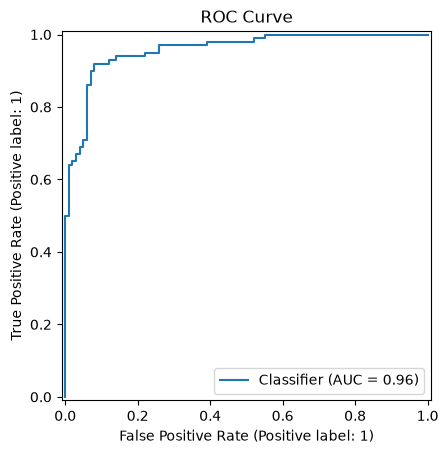

,threshold,false_positive_rate,true_positive_rate
0,inf,0.00,0.00
1,0.999516,0.00,0.01
2,0.920950,0.00,0.50
3,0.919208,0.01,0.50
4,0.849381,0.01,0.64
5,0.823148,0.02,0.64
6,0.819807,0.02,0.65
7,0.778887,0.03,0.65
8,0.766854,0.03,0.67
9,0.743637,0.04,0.67


In [23]:
y_pred = log_reg.predict(X_val)
y_pred_proba = log_reg.predict_proba(X_val)[:, 1]
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_pred_proba):.4f}")

# Plot ROC-AUC
RocCurveDisplay.from_predictions(
    y_val,
    y_pred_proba
)

plt.title("ROC Curve")
plt.show()


# See the table for thresholds to decide the threshold
fpr, tpr, thresholds = roc_curve(
    y_val,
    y_pred_proba
)

roc_table = pd.DataFrame({
    "threshold": thresholds,
    "false_positive_rate": fpr,
    "true_positive_rate": tpr
})

roc_table.head(20)

## 9. Regression

Predicting a continuous numerical target.

* **Regression Target:** A continuous variable (e.g., price, temperature).
* **Linear Regression:** Fits a straight line (or hyperplane) by minimizing the sum of squared residuals.
* **Decision Tree Regressor:** Splits data and predicts the mean value of the target in the leaf nodes.
* **Random Forest Regressor:** Averages the numerical predictions of multiple decision trees.
* **Residuals:** The difference between the actual value and the predicted value ($y_i - \hat{y}_i$).

In [24]:
X_reg, y_reg = make_regression(n_samples=500, n_features=2, noise=15.0, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_r = lin_reg.predict(X_test_r)

## 10. Regression Metrics

* **MAE (Mean Absolute Error):** Average of absolute residuals. Robust to outliers. 
  $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **MSE (Mean Squared Error):** Average of squared residuals. Penalizes large errors heavily; sensitive to outliers.
  $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
* **RMSE (Root Mean Squared Error):** Square root of MSE. Keeps units aligned with the target.
  $$RMSE = \sqrt{MSE}$$
* **$R^2$ (Coefficient of Determination):** Proportion of variance in the target explained by the model. $1.0$ is perfect; $0.0$ is equivalent to a mean baseline.
  $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
* **MAPE (Mean Absolute Percentage Error):** Useful for relative business interpretation but fails or blows up if actual values are near zero.

In [ ]:
print(f"MAE:  {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"MSE:  {mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")
print(f"R^2:  {r2_score(y_test_r, y_pred_r):.4f}")

MAE:  10.7331
MSE:  196.1327
RMSE: 14.0047
R^2:  0.6383


## 11. Overfitting and Underfitting

* **Underfitting (High Bias):** The model is too simple to capture the underlying pattern. Poor performance on both training and validation sets.
* **Overfitting (High Variance):** The model is too complex and memorizes the noise/fluctuations in the training data. Excellent training performance, but terrible validation performance.
* **Bias-Variance Trade-off:** The balance between a model's flexibility to fit the data (low bias, high variance) and its simplicity (high bias, low variance).
* **Model Complexity:** Increasing complexity (e.g., deeper trees, higher polynomial degrees) reduces bias but increases variance.
* **Generalization Error:** The difference between validation/test error and training error.

In [26]:
# Generating a simple non-linear dataset
np.random.seed(42)
X_poly = np.linspace(-3, 3, 100).reshape(-1, 1)
y_poly = np.sin(X_poly).ravel() + np.random.normal(0, 0.3, 100)

X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(X_poly, y_poly, test_size=0.3, random_state=42)

for degree in [1, 3, 20]: # Low degree (underfit), suitable, high degree (overfit)
    pipe = Pipeline([('poly', PolynomialFeatures(degree)), ('lin', LinearRegression())])
    pipe.fit(X_train_p, y_train_p)
    train_score = pipe.score(X_train_p, y_train_p)
    val_score = pipe.score(X_val_p, y_val_p)
    print(f"Degree {degree:>2} -> Train R2: {train_score: .3f} | Val R2: {val_score: .3f}")

Degree  1 -> Train R2:  0.520 | Val R2:  0.619
Degree  3 -> Train R2:  0.876 | Val R2:  0.919
Degree 20 -> Train R2:  0.156 | Val R2: -0.771


## 12. Cross-Validation

* **k-fold Cross-Validation:** Dividing data into $k$ equal subsets (folds). The model is trained on $k-1$ folds and validated on the remaining fold, repeating $k$ times. Output is an array of $k$ scores.
* **Stratified k-fold:** Ensures class distributions are maintained across folds.
* **Repeated Cross-Validation:** Runs k-fold multiple times with different random splits to reduce variance.
* **Time-Series Split:** Prevents future data from leaking into past training data by sliding a training window forward in time.
* **Why useful:** Provides a much more reliable estimate of model performance than a single validation split.
* **Drawback:** Computationally expensive (trains the model $k$ times).
* **Leakage Warning:** Always wrap preprocessing inside a `Pipeline` before passing to CV. If you preprocess the whole dataset *before* CV, data leaks into the validation folds.

In [ ]:
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train, y_train, cv=skf, scoring='accuracy')

print("CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
#  A scikit-learn Pipeline combines preprocessing and model training into a single reusable workflow.
#  During fitting, each preprocessing step is learned only from the training data, and during prediction the same learned transformations are applied to new data.
#  Pipelines reduce repetitive code, prevent data leakage, and work cleanly with cross-validation and hyperparameter tuning.

CV Scores: [0.86666667 0.84166667 0.85833333 0.85833333 0.81666667]
Mean CV Accuracy: 0.8483 +/- 0.0178


## 13. Hyperparameters and Model Tuning

* **Parameter vs Hyperparameter:** Parameters are learned (e.g., weights). Hyperparameters are set manually before training (e.g., `max_depth` of a tree).
* **Search Space:** The defined boundaries of values for the hyperparameters to explore.
* **Grid Search:** Exhaustively tests every possible combination in the search space. Slow but thorough. Don't use for large datasets
* **Random Search:** Samples combinations randomly from a statistical distribution. Generally faster and more efficient for high-dimensional spaces.
* **Validation Score Optimization:** Tuning algorithms use cross-validation scores to find the best configuration.

**Crucial Rule:** Hyperparameter tuning must NEVER involve the final Test Set. Tuning on the test set effectively leaks information, making the test set a secondary validation set.

In [36]:
param_grid = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10]
}

dt_clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_clf, param_grid, cv=3, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': 5, 'min_samples_split': 2}
Best CV Score: 0.8733


## 14. Feature Engineering

Creating new, highly predictive features from existing data. Better features often beat better algorithms.

* **Domain Knowledge:** The most powerful tool. Understanding the real-world problem to engineer relevant metrics.
* **Interaction Features:** Multiplying or dividing two features (e.g., `Length` * `Width` = `Area`).
* **Polynomial Features:** Squaring or cubing variables to capture non-linear relationships.
* **Ratios:** e.g., `Debt` / `Income`.
* **Date/Time Decomposition:** Extracting `DayOfWeek`, `Month`, `IsHoliday` from a timestamp.
* **Log Transformation:** Normalizing heavily skewed data.
* **Binning:** Converting continuous variables into categories (e.g., Age ranges).
* **Target Leakage:** Beware of creating features using information that wouldn't actually be available at prediction time.

In [37]:
# Small example of engineered features on a pandas DataFrame
df_fe = pd.DataFrame({'Length': [10, 20, 15], 'Width': [5, 10, 5], 'Price': [1000, 4500, 2000]})
df_fe['Area'] = df_fe['Length'] * df_fe['Width'] # Interaction
df_fe['Price_per_Area'] = df_fe['Price'] / df_fe['Area'] # Ratio
df_fe['Log_Price'] = np.log(df_fe['Price']) # Transformation
print(df_fe)

   Length  Width  Price  Area  Price_per_Area  Log_Price
0      10      5   1000    50       20.000000   6.907755
1      20     10   4500   200       22.500000   8.411833
2      15      5   2000    75       26.666667   7.600902


## 15. Feature Selection and Dimensionality

Reducing the number of features to combat the **Curse of Dimensionality** (where data becomes sparse in high-dimensional space, hurting performance).

* **Irrelevant Features:** Add noise.
* **Redundant Features:** Highly correlated with other features (Multicollinearity), making models unstable or uninterpretable.
* **Filter Methods:** Statistical tests (e.g., ANOVA, correlation) independent of any ML model.
* **Wrapper Methods:** Iteratively training models to add/remove features based on performance (e.g., Recursive Feature Elimination).
* **Embedded Methods:** Feature selection built into algorithm training (e.g., L1 Regularization, Tree feature importance).
* **Important Warning:** High Feature Importance means a feature is highly predictive for the model, but it **does not imply causality**.

In [41]:
# Filter Method: SelectKBest
selector = SelectKBest(score_func=f_classif, k=5) # Select top 5 features
X_train_selected = selector.fit_transform(X_train, y_train)
print("Original shape:", X_train.shape, "-> Selected shape:", X_train_selected.shape)

# Embedded Method: Random Forest Importance
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print("Top 3 Feature Importances:", sorted(rf.feature_importances_, reverse=True)[:3])

Original shape: (600, 20) -> Selected shape: (600, 5)
Top 3 Feature Importances: [np.float64(0.31082854629843004), np.float64(0.18566183380909876), np.float64(0.09413628715247473)]


## 16. Regularization

Regularization adds a mathematical penalty to the loss function to discourage large coefficients, controlling model complexity to prevent overfitting.

* **L1 Regularization (Lasso):** Penalizes the absolute value of coefficients. It can shrink some coefficients exactly to zero, performing built-in feature selection.
* **L2 Regularization (Ridge):** Penalizes the squared value of coefficients. It shrinks coefficients close to zero, but rarely exactly zero. Handles multicollinearity well.
* **Elastic Net:** A combination of L1 and L2 penalties.
* **Penalty Strength (often denoted as $C$ or $\alpha$):** Determines how heavily we penalize complexity. In scikit-learn LogisticRegression, a smaller $C$ means *stronger* regularization. In Ridge/Lasso, a higher $\alpha$ means *stronger* regularization.
* **Scaling Matters:** Always scale the numeric values since regularization penalizes coefficient sizes. Without scaling, coefficients are affected by the units of each feature.

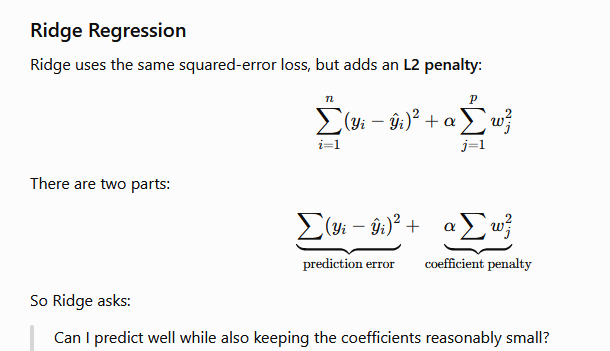
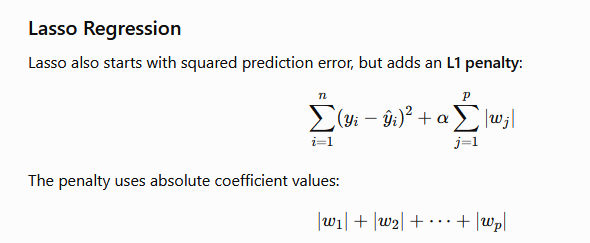

In [ ]:
# Regularization tells the model: Fit the data well, but keep the model reasonably simple. So it prevents overfitting.
ridge_reg = Ridge(alpha=10.0)
lasso_reg = Lasso(alpha=0.1)

ridge_reg.fit(X_train_r, y_train_r)
lasso_reg.fit(X_train_r, y_train_r)

print("Ridge Non-zero coefficients:", np.sum(ridge_reg.coef_ != 0))
print("Lasso Non-zero coefficients:", np.sum(lasso_reg.coef_ != 0))

Ridge Non-zero coefficients: 2
Lasso Non-zero coefficients: 2


## 17. Probability Outputs and Calibration

* **Predicted Probability vs Confidence:** A model outputting 0.9 probability doesn't strictly mean there is a 90% real-world chance of the event. It's just the model's internal score.
* **Calibration:** A perfectly calibrated model outputs probabilities matching reality (e.g., out of 100 predictions of 80% probability, exactly 80 should be True).
* **Brier Score / Log Loss:** Metrics explicitly designed to evaluate the quality of predicted probabilities, not just the hard classifications.
* **Why Calibration Matters:** A model can have 99% accuracy but terrible calibration if its probability outputs are all skewed to extremes.

True probabilities in bins: [0.05633803 0.25925926 0.64285714 0.80952381 0.94029851]
Mean predicted probabilities: [0.08264048 0.28107367 0.53360797 0.7144549  0.93097185]


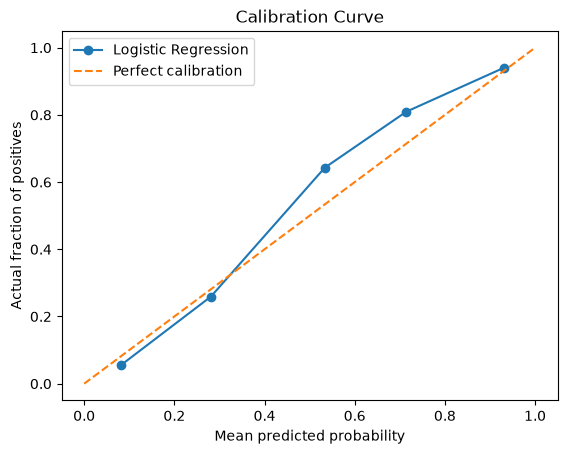

In [53]:
y_prob = log_reg.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5)
print("True probabilities in bins:", prob_true)
print("Mean predicted probabilities:", prob_pred)

# Plot the calibration curve
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## 18. Class Imbalance

When the target variable is highly skewed (e.g., 99% Negative, 1% Positive).

* **Class Weights:** Adjusting the algorithm's loss function to penalize mistakes on the minority class much more heavily.
* **Undersampling:** Randomly removing samples from the majority class to balance the dataset.
* **Oversampling:** Duplicating samples from the minority class.
* **SMOTE (Synthetic Minority Over-sampling Technique):** Synthesizing new minority class data points by interpolating between existing ones.
* **Threshold Adjustment:** Lowering the decision threshold (e.g., from 0.5 to 0.2) to catch more positive cases at the expense of false positives.
* **Suitable Metrics:** Rely on PR-AUC, F1-Score, and recall rather than accuracy.

In [57]:
# Simulating class weights implementation
clf_balanced = LogisticRegression(class_weight='balanced', random_state=42)
clf_balanced.fit(X_train, y_train)
y_pred_bal = clf_balanced.predict(X_val)
print("Balanced Recall:", recall_score(y_val, y_pred_bal))


Balanced Recall: 0.86


## 19. Data Leakage

Data leakage is the most fatal flaw in ML modeling, resulting in overly optimistic validation scores that collapse in production.

* **Target Leakage:** Including features that are a direct result of the target (e.g., using `discharge_date` to predict `patient_survival`).
* **Train-Test Contamination:** Evaluating the model on data it has already seen.
* **Preprocessing Leakage:** Calling `scaler.fit()` or `imputer.fit()` on the entire dataset *before* splitting `train_test_split`. 
* **Future Information:** Using data point $t+1$ to predict $t$ in time series.
* **Duplicate Leakage:** If duplicate rows exist and span across train and test splits, the test set is compromised.

**Correction:** ALWAYS split data first. ALWAYS use Pipelines for cross-validation.

## 20. Model Interpretation

Understanding *how* and *why* a model makes its predictions.

* **Model Coefficients (Linear Models):** Provide direction and magnitude of a feature's effect, assuming features are scaled and independent.
* **Feature Importance (Tree Models):** Shows how much a feature contributes to reducing impurity across trees. Does not give direction (positive/negative).
* **Permutation Importance:** A model-agnostic technique measuring how much the performance metric drops when a single feature's data is randomly shuffled.
* **Partial Dependence:** Visualizes the marginal effect of a feature on the predicted outcome.
* **Local vs Global Explanations:** Global (how the model works overall) vs Local (why the model made a specific prediction for one single row).
* **Correlation vs Causation:** A model finds mathematical associations. Even the strongest predictor might not be the actual cause of the event.

In [58]:
perm_importance = permutation_importance(log_reg, X_val, y_val, n_repeats=5, random_state=42)
print("Top Feature Permutation Importance Mean:", np.max(perm_importance.importances_mean))

Top Feature Permutation Importance Mean: 0.29400000000000004


## 21. Unsupervised Learning Overview

Algorithms that discover hidden structures in data without labeled targets.

* **Clustering (e.g., K-Means):** Grouping similar data points together. K-Means partitions data into $K$ clusters by minimizing variance within clusters.
* **Dimensionality Reduction (e.g., PCA):** Reducing feature space while retaining variance. Principal Component Analysis transforms features into new, uncorrelated orthogonal axes.
* **Anomaly Detection (e.g., Isolation Forest):** Identifying rare events or outliers by isolating them rapidly in tree structures.

In [59]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X_train)
print("PCA shape:", X_pca.shape, "| Outliers found:", np.sum(outliers == -1))

PCA shape: (600, 2) | Outliers found: 30


## 22. Common ML Algorithms Cheat Sheet

| Algorithm | Problem Type | Main Idea | Advantages | Weaknesses | Important Hyperparameters | Scaling Req? | Handles Non-linear? | Interpretable? |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Linear/Log Regression** | Reg / Class | Fits a line/hyperplane | Fast, simple, baseline | Fails on complex non-linear data | Regularization ($C$, $\alpha$) | Yes | No | Highly |
| **Decision Tree** | Both | Splits data via rules | Handles mixed data easily | Highly prone to overfitting | `max_depth`, `min_samples_split` | No | Yes | Highly |
| **Random Forest** | Both | Averages many trees | Powerful, robust to outliers | Slower inference, large memory | `n_estimators`, `max_depth` | No | Yes | Moderate |
| **Gradient Boosting** | Both | Trees correct previous errors | High performance winner | Prone to overfitting if un-tuned | `learning_rate`, `n_estimators` | No | Yes | Moderate |
| **KNN** | Both | Predicts via nearest points | Simple math, no training phase | Extremely slow at inference | `n_neighbors` ($k$) | Yes | Yes | Moderate |
| **SVM** | Both | Maximizes margin between classes | Effective in high dims | Poor scaling to large datasets | Kernel type, $C$, Gamma | Yes | Yes (w/ Kernel) | Low |
| **Naive Bayes** | Class | Bayes' Theorem w/ independence | Fast, great for text | Independence assumption is flawed | Smoothing ($\alpha$) | No | No | Moderate |
| **K-Means** | Clustering | Minimizes within-cluster variance | Fast, intuitive | Must choose K, assumes spherical | `n_clusters` ($k$) | Yes | N/A | High |
| **PCA** | Dim Reduct. | Orthogonal variance projection | Reduces collinearity visually | Loses feature interpretability | `n_components` | Yes | Linear only | Low |

## 23. Common Practical Mistakes

1. Evaluating model performance on the training data.
2. Using the final test set iteratively during hyperparameter tuning.
3. Fitting scalers, imputers, or encoders on the entire dataset before splitting.
4. Relying strictly on accuracy when dealing with imbalanced classes.
5. Ignoring data leakage, leading to "too good to be true" models.
6. Using arbitrary database IDs or timestamps as predictive numerical features without feature engineering.
7. Confusing high feature correlation or importance with direct causation.
8. Deploying a complex Deep Learning / Ensemble model without checking a simple Baseline first.
9. Using dozens of different evaluation metrics without actually understanding what they measure for the specific business problem.
10. Forgetting to set a random state, destroying reproducibility.
11. Deploying a model and never monitoring it for data drift over time.

## 24. End-to-End Mini Example

A synthetic workflow highlighting best practices.

In [61]:
# 1. Define / Generate Data
X_end, y_end = make_classification(n_samples=2000, n_features=10, n_informative=5, random_state=42)
print("Dataset Shape:", X_end.shape)

# 2. Split Data (Holdout Test Set)
X_e_train, X_e_test, y_e_train, y_e_test = train_test_split(X_end, y_end, test_size=0.2, stratify=y_end, random_state=42)

# 3. Preprocess via Pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

# 4. Cross-Validation (on Training Data)
cv_scores_e = cross_val_score(pipe_lr, X_e_train, y_e_train, cv=5, scoring='f1')
print(f"LR CV F1 Score: {cv_scores_e.mean():.4f}")

# 5. Train & Evaluate final model on Test Set
pipe_lr.fit(X_e_train, y_e_train)
y_e_pred = pipe_lr.predict(X_e_test)
y_e_proba = pipe_lr.predict_proba(X_e_test)[:, 1]

# 6. Metrics Analysis
print("\nTest Set Confusion Matrix:\n", confusion_matrix(y_e_test, y_e_pred))
print("Test Set Accuracy:", accuracy_score(y_e_test, y_e_pred))
print("Test Set ROC-AUC:", roc_auc_score(y_e_test, y_e_proba))

# 7. Compare with Baseline / Alternative
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_e_train, y_e_train)
rf_pred = pipe_rf.predict(X_e_test)
print("\nRF Test Set Accuracy:", accuracy_score(y_e_test, rf_pred))

Dataset Shape: (2000, 10)
LR CV F1 Score: 0.7997

Test Set Confusion Matrix:
 [[152  48]
 [ 39 161]]
Test Set Accuracy: 0.7825
Test Set ROC-AUC: 0.8379749999999999

RF Test Set Accuracy: 0.895


## 25. ML Terminology Glossary

* **accuracy:** The proportion of correct predictions out of all predictions.
* **algorithm:** The set of rules the model uses to learn patterns.
* **baseline:** A simple heuristic model used as a minimum benchmark.
* **bias:** Error introduced by approximating a real-world problem too simplistically (underfitting).
* **calibration:** Ensuring predicted probabilities match empirical observation frequencies.
* **class imbalance:** A heavily unequal distribution of classes in the target variable.
* **classification:** Supervised learning where the target is a discrete category.
* **confusion matrix:** A $2 \times 2$ (or larger) table detailing True/False Positives/Negatives.
* **cross-validation:** Iterative splitting method to obtain robust performance estimates.
* **data leakage:** Inadvertently sharing information between the training and validation/test sets.
* **decision boundary:** The mathematical threshold dividing different predicted classes.
* **epoch:** One complete pass through the entire training dataset (common in deep learning).
* **estimator:** The core object in scikit-learn that implements `fit()` and `predict()`.
* **feature:** An input variable or column.
* **feature engineering:** Creating new inputs based on domain knowledge.
* **fit:** The process of training an estimator on data.
* **generalization:** How accurately a model performs on unseen, new data.
* **hyperparameter:** Configurations set prior to training (e.g., learning rate).
* **inference:** The act of making predictions on new data.
* **label:** The target or true outcome.
* **loss function:** The mathematical penalty a model tries to minimize during training.
* **metric:** An evaluation equation used to measure the quality of predictions.
* **model:** The mathematical object containing the learned parameters.
* **overfitting:** Memorizing noise in the training data, leading to poor generalization.
* **parameter:** Internal variable learned by the model from the data.
* **pipeline:** Chaining multiple preprocessing steps and an estimator together to prevent leakage.
* **predict:** Outputting the final class or numerical estimate.
* **predicted probability:** The model's numerical confidence in its class prediction.
* **preprocessing:** Data cleaning, scaling, and transformation prior to modeling.
* **recall:** The ability of the model to find all positive samples (True Positive Rate).
* **regression:** Supervised learning where the target is continuous.
* **regularization:** Penalizing complexity to prevent overfitting.
* **sample:** A single row of data.
* **scaling:** Standardizing or normalizing numeric ranges.
* **target:** What you are trying to predict.
* **test set:** Unseen holdout data evaluated exactly once at the end.
* **training set:** Data used to compute and learn parameters.
* **underfitting:** Failing to capture the underlying pattern of the data.
* **validation set:** Holdout data used repeatedly to tune hyperparameters.
* **variance:** Sensitivity of the model to small fluctuations in the training data (overfitting).

## 26. Self-Check Questions

1. Why should preprocessing be inside a pipeline?
2. Why is accuracy insufficient for imbalanced data?
3. What is the difference between a parameter and a hyperparameter?
4. What is the difference between validation and test data?
5. Why can high training accuracy be a warning sign?
6. When should standardization be used?
7. Why can a feature cause leakage?
8. What does cross-validation estimate?
9. Why is a baseline important?
10. What is probability calibration?

<details>
<summary><strong>Click to reveal answers</strong></summary>

1. To prevent data leakage; the test/validation folds must be processed using statistics (like mean) learned *only* from the training folds.
2. A model can achieve 99% accuracy by simply predicting the majority class, completely failing to detect the minority class you likely care about.
3. A parameter is learned internally by the algorithm during training. A hyperparameter is set externally by the engineer before training begins.
4. Validation data is used iteratively to adjust and tune the model. Test data is completely isolated and used only once for a final unbiased evaluation.
5. It usually indicates overfitting—the model has memorized the training data and its noise, and will likely fail on unseen data.
6. When using algorithms sensitive to distance or scale, such as SVMs, KNN, PCA, or models using regularization (Ridge/Lasso).
7. If a feature contains information that mathematically could not be known at the time of prediction (e.g., "account canceled date" predicting "churn"), it ruins the model.
8. It provides a more robust estimate of how the model is expected to generalize on independent, unseen datasets compared to a single train/test split.
9. It provides a sanity check. If a complex neural network cannot outperform a naive guess (like predicting the mean), the modeling approach is flawed.
10. Ensuring that a model's predicted probabilities align with the actual real-world frequencies of the event occurring.
</details>

## 27. Final Summary

The core principles of practical machine learning:

* **Build a baseline first:** Never jump to complex models without establishing a simplistic minimum threshold.
* **Keep test data untouched:** The test set is a strict final exam, not a study guide.
* **Prevent leakage:** Separate train and test data *before* doing any imputation or scaling.
* **Preprocess through pipelines:** Automate and secure your data transformations to prevent cross-validation leakage.
* **Select metrics based on the problem:** Do not default to accuracy; understand precision, recall, and your business objective.
* **Compare training and validation performance:** Diagnosing overfitting and underfitting is your primary debugging tool.
* **Use cross-validation:** Ensure your model's estimated performance is reliable.
* **Report uncertainty and limitations:** Models output estimates, not absolute truths.
* **Prioritize generalization over training performance:** A model that scores 100% on training data is almost certainly useless in production.
* **Keep experiments reproducible:** Always set global random seeds (`random_state`).